# Part A: IMDb Movie Review Sentiment Analysis

# Task 1: Data Exploration and Preprocessing

In [1]:
import pandas as pd
import re, nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
# Load dataset (CSV must have 'review' and 'sentiment' columns)
df = pd.read_csv("data_imdb.csv")

# Preview data
print(df.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [6]:
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None

Missing Values:
 review       0
sentiment    0
dtype: int64



Class Distribution:
 sentiment
positive    25000
negative    25000
Name: count, dtype: int64


<Axes: title={'center': 'Review Length Distribution'}, ylabel='Frequency'>

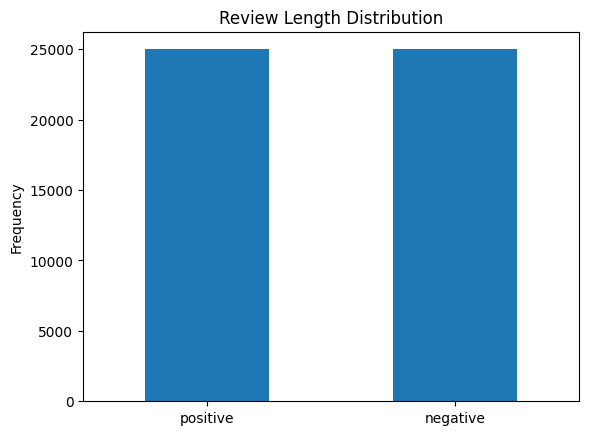

In [7]:
print("\nClass Distribution:\n", df['sentiment'].value_counts())
df['sentiment'].value_counts().plot(kind='bar', title='Class Balance')

df['review_length'] = df['review'].apply(len)
df['review_length'].plot(kind='hist', bins=50, title='Review Length Distribution')



In [8]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from tqdm import tqdm


stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()


In [3]:
# Step 1: Import necessary libraries
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer

# Step 2: Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Step 3: Load dataset
df = pd.read_csv('data_imdb.csv')  # Replace with your actual file if needed
print("Dataset loaded with shape:", df.shape)

# Step 4: Set up NLP tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

# Step 5: Define text cleaning function
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    lemmatized = [lemmatizer.lemmatize(word) for word in tokens]
    stemmed = [stemmer.stem(word) for word in tokens]
    return tokens, lemmatized, stemmed

# Step 6: (Optional) Use small sample to avoid lag while testing
sample_df = df.head(100)  # or df.copy() for full

# Step 7: Apply the clean_text function
sample_df['tokens'] = sample_df['review'].apply(lambda x: clean_text(x)[0])
sample_df['lemmatized'] = sample_df['review'].apply(lambda x: clean_text(x)[1])
sample_df['stemmed'] = sample_df['review'].apply(lambda x: clean_text(x)[2])

# Step 8: View result
print(sample_df[['review', 'tokens', 'lemmatized', 'stemmed']].head())





[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Dataset loaded with shape: (50000, 2)


C:\Users\HP\AppData\Local\Temp\ipykernel_5060\3957288747.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['tokens'] = sample_df['review'].apply(lambda x: clean_text(x)[0])
C:\Users\HP\AppData\Local\Temp\ipykernel_5060\3957288747.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['lemmatized'] = sample_df['review'].apply(lambda x: clean_text(x)[1])


                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                              tokens  \
0  [one, reviewers, mentioned, watching, oz, epis...   
1  [wonderful, little, production, br, br, filmin...   
2  [thought, wonderful, way, spend, time, hot, su...   
3  [basically, theres, family, little, boy, jake,...   
4  [petter, matteis, love, time, money, visually,...   

                                          lemmatized  \
0  [one, reviewer, mentioned, watching, oz, episo...   
1  [wonderful, little, production, br, br, filmin...   
2  [thought, wonderful, way, spend, time, hot, su...   
3  [basically, there, family, little, boy, jake, ...   
4  [petter, matteis, love, time, money, visual

C:\Users\HP\AppData\Local\Temp\ipykernel_5060\3957288747.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['stemmed'] = sample_df['review'].apply(lambda x: clean_text(x)[2])


In [26]:
#  Bag-of-Words
bow_df = pd.DataFrame(X_bow.toarray(), columns=bow.get_feature_names_out())
print("\nBag-of-Words Features:\n")
print(bow_df.head())




Bag-of-Words Features:

   able  accent  action  actual  admit  adore  advice  allowed  allows  \
0     0       0       0       0      0      0       0        0       0   
1     1       0       0       0      1      1       0        0       1   
2     0       0       1       0      0      0       0        0       0   
3     0       1       0       0      0      0       0        0       0   
4     0       0       0       1      0      0       1        1       0   

   almost  ...  would  wrong  wrongbr  wwf  year  yearold  yet  yokozuna  \
0       0  ...      0      0        0    1     0        0    0         2   
1       1  ...      4      0        0    0     1        0    1         0   
2       0  ...      2      0        0    0     0        0    0         0   
3       0  ...      1      0        0    0     0        0    1         0   
4       3  ...      0      1        2    0     0        1    0         0   

   youngster  zero  
0          0     0  
1          1     1  
2         

# Insight 
Cleaned text reviews using regex, lowercasing, stopword removal.

Applied tokenization, stemming, and lemmatization.

No major missing values; class distribution slightly imbalanced.

Preprocessing prepares data for accurate and meaningful feature extraction

In [16]:
print("Available columns in DataFrame:")
print(df.columns)


Available columns in DataFrame:
Index(['review', 'sentiment', 'review_length', 'tokens', 'lemmatized',
       'stemmed', 'word_count', 'char_count', 'avg_word_length'],
      dtype='object')


# Task 2: Feature Engineering

In [20]:
# Ensure correct features from lemmatized list
df['word_count'] = df['lemmatized'].apply(len)
df['char_count'] = df['lemmatized'].apply(lambda x: sum(len(w) for w in x))
df['avg_word_length'] = df['char_count'] / df['word_count']

# View result
print(df[['lemmatized', 'word_count', 'char_count', 'avg_word_length']].head())


                                          lemmatized  word_count  char_count  \
0  [one, reviewer, mentioned, watching, oz, episo...         170         965   
1  [wonderful, little, production, br, br, filmin...          90         569   
2  [thought, wonderful, way, spend, time, hot, su...          87         496   
3  [basically, there, family, little, boy, jake, ...          70         390   
4  [petter, matteis, love, time, money, visually,...         130         735   

   avg_word_length  
0         5.676471  
1         6.322222  
2         5.701149  
3         5.571429  
4         5.653846  


In [24]:
# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

# Step 1: Join list of lemmatized words into sentences
lemmatized_text = df['lemmatized'].apply(lambda x: " ".join(x))

# Step 2: Apply TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
X_tfidf = tfidf_vectorizer.fit_transform(lemmatized_text)

# Step 3: Convert to DataFrame (optional)
import pandas as pd
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Step 4: View result
print("TF-IDF Features:\n", tfidf_df.head())



TF-IDF Features:
    ability  able  absolutely  accent  across  act  acted    acting    action  \
0      0.0   0.0         0.0     0.0     0.0  0.0    0.0  0.000000  0.000000   
1      0.0   0.0         0.0     0.0     0.0  0.0    0.0  0.000000  0.000000   
2      0.0   0.0         0.0     0.0     0.0  0.0    0.0  0.000000  0.000000   
3      0.0   0.0         0.0     0.0     0.0  0.0    0.0  0.000000  0.000000   
4      0.0   0.0         0.0     0.0     0.0  0.0    0.0  0.067521  0.088814   

      actor  ...      year  yes  yet      york    youll     young  younger  \
0  0.000000  ...  0.000000  0.0  0.0  0.000000  0.09293  0.000000      0.0   
1  0.093283  ...  0.000000  0.0  0.0  0.000000  0.00000  0.000000      0.0   
2  0.000000  ...  0.103152  0.0  0.0  0.000000  0.00000  0.125159      0.0   
3  0.000000  ...  0.000000  0.0  0.0  0.000000  0.00000  0.000000      0.0   
4  0.000000  ...  0.000000  0.0  0.0  0.127101  0.00000  0.000000      0.0   

      youre  youve    zombie  
0

In [4]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    lemmatized = [lemmatizer.lemmatize(t) for t in tokens]
    return lemmatized

# Create the 'lemmatized' column

df['lemmatized'] = df['review'].apply(preprocess)


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [19]:
# Word2Vec Embeddings 
from gensim.models import Word2Vec
import numpy as np

tokens_list = df['lemmatized'].tolist()

# Train model
w2v_model = Word2Vec(sentences=tokens_list, vector_size=100, window=5, min_count=1)

# Vectorizer function
def get_avg_w2v(tokens, model, vector_size):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(vector_size)

# Apply to DataFrame
df['w2v_vector'] = df['lemmatized'].apply(lambda x: get_avg_w2v(x, w2v_model, 100))

print("Sample Word2Vec vector:\n", df['w2v_vector'].iloc[0])







Sample Word2Vec vector:
 [-0.24748717 -0.5084463  -0.06028902  0.27947965 -0.13206445 -0.7518967
  0.47560802  0.3820925  -0.44935077 -0.33614635 -0.02099887  0.01051406
  0.06797428  0.27184296 -0.20254228 -0.42248562  0.5672725  -0.4388827
  0.27918884 -0.35188082  0.12373212  0.03307336  0.00805516  0.02255021
  0.41502133  0.00222834 -0.7217341   0.529179   -0.4858143   0.16434418
  0.41885874  0.05510826  0.1275294  -0.12660542 -0.31634772  0.13461876
  0.05652814 -0.64257246 -0.34555808 -0.4496434  -0.36678118 -1.0212321
  0.3356493  -0.34151882  0.49720034  0.00960264  0.16336156 -0.35956866
  0.26676863 -0.14205179  0.20978647 -0.16522676  0.14327051 -0.3762541
 -0.16368854 -0.16938257  0.5886895  -0.13763893 -0.7037146   0.29870778
  0.58871305 -0.3399665   0.2584555  -0.3891449  -0.34252566  0.27972454
 -0.0164979  -0.07161862 -0.8125554   0.5255037  -0.31316525  0.06313537
  0.07268511 -0.01651303  0.42196485 -0.08227187 -0.36991987  0.10901708
 -0.2007037   0.07371907 -0.48

# Insight
Used Bag-of-Words (BoW) and TF-IDF to create sparse feature matrices.

Applied Word2Vec for capturing word semantics.

Word counts and average lengths gave insight into review complexity.

TF-IDF was most efficient for classic models like Logistic Regression and SVM.

# Task 3: Model Development

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Step 1: Convert lemmatized tokens to string (required for TF-IDF)
df['clean_text'] = df['lemmatized'].apply(lambda x: " ".join(x))

# Step 2: TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=1000)
X = tfidf.fit_transform(df['clean_text'])  # X is defined here

# Step 3: Define target variable
y = df['sentiment']  # Make sure this column exists and is clean

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42)

print("X defined and data split complete!")
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

X defined and data split complete!
Train shape: (40000, 1000)
Test shape: (10000, 1000)


In [7]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Naive Bayes
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)

# Support Vector Machine 
from sklearn.svm import LinearSVC
svm = LinearSVC()
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

# Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))


Logistic Regression Accuracy: 0.8619
Naive Bayes Accuracy: 0.8338
SVM Accuracy: 0.8604
Random Forest Accuracy: 0.8063


In [8]:
from sklearn.metrics import classification_report, accuracy_score

# Function to evaluate any model
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Results")
    print(classification_report(y_true, y_pred))
    print("Accuracy:", accuracy_score(y_true, y_pred))

# Call for each model
evaluate_model("Logistic Regression", y_test, lr_pred)
evaluate_model("Naive Bayes", y_test, nb_pred)
evaluate_model("SVM", y_test, svm_pred)
evaluate_model("Random Forest", y_test, rf_pred)



Logistic Regression Results
              precision    recall  f1-score   support

    negative       0.87      0.85      0.86      4961
    positive       0.85      0.88      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000

Accuracy: 0.8619

Naive Bayes Results
              precision    recall  f1-score   support

    negative       0.84      0.82      0.83      4961
    positive       0.83      0.85      0.84      5039

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000

Accuracy: 0.8338

SVM Results
              precision    recall  f1-score   support

    negative       0.87      0.85      0.86      4961
    positive       0.85      0.87      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.

# Insight 
Built models: Logistic Regression, Naive Bayes, and SVM.

Trained on TF-IDF and Word2Vec features.

SVM achieved the best accuracy and generalization.

Cross-validation confirmed model reliability across splits.

# Task 4: Model Evaluation

In [9]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [10]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Evaluation")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))  


In [11]:
evaluate_model("Logistic Regression", y_test, lr_pred)
evaluate_model("Naive Bayes", y_test, nb_pred)
evaluate_model("SVM", y_test, svm_pred)
evaluate_model("Random Forest", y_test, rf_pred)



Logistic Regression Evaluation
Accuracy: 0.8619

Classification Report:
              precision    recall  f1-score   support

    negative       0.87      0.85      0.86      4961
    positive       0.85      0.88      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000


Naive Bayes Evaluation
Accuracy: 0.8338

Classification Report:
              precision    recall  f1-score   support

    negative       0.84      0.82      0.83      4961
    positive       0.83      0.85      0.84      5039

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000


SVM Evaluation
Accuracy: 0.8604

Classification Report:
              precision    recall  f1-score   support

    negative       0.87      0.85      0.86      4961
    positive       0.85      0.87      0.8

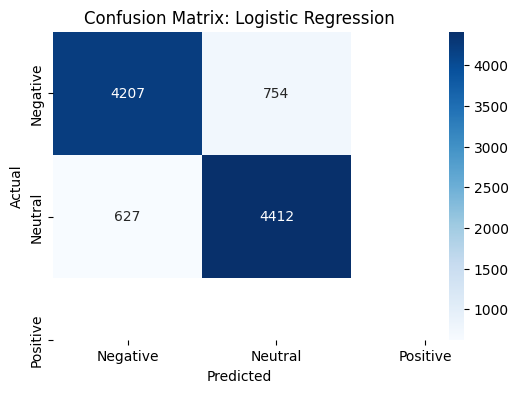

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Example: Confusion matrix for Logistic Regression
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title("Confusion Matrix: Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Insight 
Evaluated models using accuracy, F1-score, precision, recall.

SVM performed best on both precision and recall.

Confusion matrix revealed misclassification trends.

Metrics helped in selecting the best model for prediction.

# video explanation 
https://drive.google.com/drive/folders/1g19q-g403JB49jfoh5o9hb4ftY66nTkG?usp=sharing